# Previsão de falhas em fresadora: quanto rende o conhecimento de manutenção

**Pergunta:** de cada 100 falhas de uma fresadora, quantas dá para antecipar com os
sensores que a máquina já tem — e quantos alarmes falsos isso custa?

A comparação central: o **mesmo modelo**, treinado duas vezes. Uma com as leituras
brutas dos sensores, outra com as mesmas leituras transformadas nas grandezas que
um técnico de manutenção olharia — potência, diferença de temperatura e esforço
acumulado da ferramenta.

Dados: *AI4I 2020 Predictive Maintenance Dataset*, UCI Machine Learning Repository.

## 1. Carregar e descrever os dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

SEMENTE = 42
df = pd.read_csv("dados/ai4i2020.csv", encoding="utf-8-sig")
print(f"{len(df):,} registros · {df.shape[1]} colunas · {df.isna().sum().sum()} valores faltantes")
df.head()

10,000 registros · 14 colunas · 0 valores faltantes


,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Cada linha é um ponto de operação de uma fresadora: temperaturas (em kelvin), rotação
(rpm), torque (N·m), minutos de uso da ferramenta e o tipo de produto (L, M ou H,
qualidade baixa, média e alta). A coluna `Machine failure` diz se houve falha.
As colunas `TWF`, `HDF`, `PWF`, `OSF` e `RNF` dizem **qual** falha foi — e por isso
**não podem entrar no modelo**: seriam a resposta disfarçada de pergunta.

In [2]:
falhas = df["Machine failure"].sum()
print(f"Falhas: {falhas} de {len(df):,} ({falhas/len(df):.1%})")
print()
nomes = {"TWF": "desgaste da ferramenta", "HDF": "dissipação de calor",
         "PWF": "potência fora da faixa", "OSF": "sobrecarga", "RNF": "aleatória"}
for col, nome in nomes.items():
    print(f"  {col}  {nome:<24} {df[col].sum():>4}")

Falhas: 339 de 10,000 (3.4%)

  TWF  desgaste da ferramenta     46
  HDF  dissipação de calor       115
  PWF  potência fora da faixa     95
  OSF  sobrecarga                 98
  RNF  aleatória                  19


Só 3,4% dos registros são falha. Isso cria a armadilha clássica: um "modelo" que
**nunca** prevê falha acerta quase tudo.

In [3]:
acerto_nunca_falha = 1 - df["Machine failure"].mean()
print(f"Acurácia de quem sempre diz 'não vai falhar': {acerto_nunca_falha:.1%}")
print("Falhas antecipadas por esse 'modelo': 0 de cada 100")

Acurácia de quem sempre diz 'não vai falhar': 96.6%
Falhas antecipadas por esse 'modelo': 0 de cada 100


Por isso a acurácia não serve como régua aqui. As duas métricas que usamos têm
significado para quem decide parar ou não uma máquina:

- **Falhas antecipadas em cada 100** — das falhas que aconteceram, quantas o alarme pegou
- **Alarmes falsos por falha pega** — quantas vezes a equipe foi chamada à toa para cada acerto

## 2. Duas versões dos mesmos dados

**Brutas:** as cinco leituras de sensor mais o tipo de produto.

**Com física da máquina:** as mesmas leituras, mais três grandezas derivadas —
exatamente o que se olha num diagnóstico de campo:

- **Potência mecânica** (W) = torque × rotação angular
- **Diferença de temperatura** entre processo e ar — mede a capacidade de dissipar calor
- **Desgaste × torque** — esforço acumulado sobre a ferramenta

In [4]:
df["tipo_M"] = (df["Type"] == "M").astype(int)
df["tipo_H"] = (df["Type"] == "H").astype(int)
df["potencia_W"] = df["Torque"] * df["Rotational speed"] * 2 * np.pi / 60
df["dif_temperatura"] = df["Process temperature"] - df["Air temperature"]
df["desgaste_x_torque"] = df["Tool wear"] * df["Torque"]

BRUTAS = ["Air temperature", "Process temperature", "Rotational speed",
          "Torque", "Tool wear", "tipo_M", "tipo_H"]
FISICA = BRUTAS + ["potencia_W", "dif_temperatura", "desgaste_x_torque"]
ALVO = "Machine failure"

## 3. Separar treino e teste

75% para treinar, 25% guardados para a avaliação final, mantendo a mesma proporção
de falhas nos dois lados. O conjunto de teste não é tocado até o fim.

In [5]:
treino, teste = train_test_split(df, test_size=0.25, stratify=df[ALVO], random_state=SEMENTE)
print(f"Treino: {len(treino):,} registros, {treino[ALVO].sum()} falhas")
print(f"Teste:  {len(teste):,} registros, {teste[ALVO].sum()} falhas")

Treino: 7,500 registros, 254 falhas
Teste:  2,500 registros, 85 falhas


## 4. O modelo — o mesmo nas duas versões

Random Forest com 300 árvores, com peso maior para a classe rara (falha).
Nenhuma busca de hiperparâmetros: a comparação é entre **dados**, não entre ajustes.

In [6]:
def novo_modelo():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  class_weight="balanced_subsample",
                                  random_state=SEMENTE, n_jobs=-1)

## 5. Onde colocar o limiar do alarme

O modelo devolve uma probabilidade de falha. O **limiar** decide a partir de quanto
o alarme dispara — baixo demais, a equipe vive correndo à toa; alto demais, a falha
passa.

**Regra de decisão, fixada antes de olhar o teste:** no máximo **1 alarme falso a
cada 2 falhas pegas**. É uma regra conservadora de propósito: alarme que erra demais
deixa de ser atendido, e aí não importa quão bom é o modelo.

O limiar é escolhido só com dados de treino, por validação cruzada em 5 partes.

In [7]:
TETO_FALSOS_POR_ACERTO = 0.5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

def escolher_limiar(colunas):
    prob = cross_val_predict(novo_modelo(), treino[colunas], treino[ALVO],
                             cv=cv, method="predict_proba")[:, 1]
    y = treino[ALVO].to_numpy()
    melhor_limiar, melhor_recall = None, -1
    for t in np.arange(0.05, 0.95, 0.01):
        alarme = prob >= t
        tp = (alarme & (y == 1)).sum()
        fp = (alarme & (y == 0)).sum()
        if tp > 0 and fp / tp <= TETO_FALSOS_POR_ACERTO:
            recall = tp / (y == 1).sum()
            if recall > melhor_recall:
                melhor_limiar, melhor_recall = round(float(t), 2), recall
    return melhor_limiar

limiares = {nome: escolher_limiar(cols) for nome, cols in [("brutas", BRUTAS), ("fisica", FISICA)]}
limiares

{'brutas': 0.36, 'fisica': 0.22}

## 6. Avaliação no teste — dados que o modelo nunca viu

In [8]:
resultados = {}
for nome, cols in [("brutas", BRUTAS), ("fisica", FISICA)]:
    modelo = novo_modelo().fit(treino[cols], treino[ALVO])
    prob = modelo.predict_proba(teste[cols])[:, 1]
    alarme = (prob >= limiares[nome]).astype(int)
    tn, fp, fn, tp = confusion_matrix(teste[ALVO], alarme).ravel()
    resultados[nome] = dict(modelo=modelo, prob=prob, alarme=alarme, tp=tp, fp=fp, fn=fn,
                            por_100=100 * tp / (tp + fn), falsos_por_acerto=fp / tp)

tabela = pd.DataFrame({
    nome: {"Limiar": limiares[nome],
           "Falhas pegas": f"{r['tp']} de {r['tp'] + r['fn']}",
           "Falhas antecipadas em cada 100": round(r["por_100"]),
           "Alarmes falsos": r["fp"],
           "Alarmes falsos por falha pega": round(r["falsos_por_acerto"], 2)}
    for nome, r in resultados.items()
}).rename(columns={"brutas": "Dados brutos", "fisica": "Com física da máquina"})
tabela

,Dados brutos,Com física da máquina
Limiar,0.36,0.22
Falhas pegas,64 de 85,73 de 85
Falhas antecipadas em cada 100,75,86
Alarmes falsos,29,31
Alarmes falsos por falha pega,0.45,0.42


### Quais falhas escapam

Olhar o que o modelo **não** pegou diz mais do que a média.

In [9]:
r = resultados["fisica"]
escaparam = teste[(teste[ALVO] == 1) & (r["alarme"] == 0)]
print(f"Falhas que escaparam (versão com física): {len(escaparam)}")
for col, nome in nomes.items():
    n = int(escaparam[col].sum())
    if n:
        print(f"  {nome:<24} {n}")
sem_modo = int((escaparam[list(nomes)].sum(axis=1) == 0).sum())
if sem_modo:
    print(f"  {'sem tipo registrado':<24} {sem_modo}")

Falhas que escaparam (versão com física): 12
  desgaste da ferramenta   10
  sem tipo registrado      2


Quase tudo o que escapa é **falha por desgaste da ferramenta**. Vale olhar quando
essas falhas acontecem — no dataset inteiro, não só no teste.

In [10]:
desgaste_twf = df.loc[df["TWF"] == 1, "Tool wear"]
print(f"Falhas por desgaste da ferramenta: {len(desgaste_twf)}")
print(f"Tempo de uso quando falharam: de {desgaste_twf.min()} a {desgaste_twf.max()} minutos")
print(f"Nenhuma aconteceu antes de {desgaste_twf.min()} minutos de uso.")

Falhas por desgaste da ferramenta: 46
Tempo de uso quando falharam: de 198 a 253 minutos
Nenhuma aconteceu antes de 198 minutos de uso.


**Isso não é problema para um modelo resolver.** A falha por desgaste aparece numa
janela estreita de tempo de uso — e o que resolve janela conhecida é **troca
preventiva por tempo**, não previsão. Nem todo problema de manutenção é problema de
IA: o modelo cobre o que depende das condições de operação, e a troca programada
cobre o que depende do relógio.

## 7. O trade-off inteiro

A regra de 1 alarme falso a cada 2 acertos é uma escolha. Esta curva mostra todas
as outras: cada ponto é um limiar possível. Uma operação onde a parada custa muito
pode aceitar mais alarmes falsos em troca de pegar mais falhas.

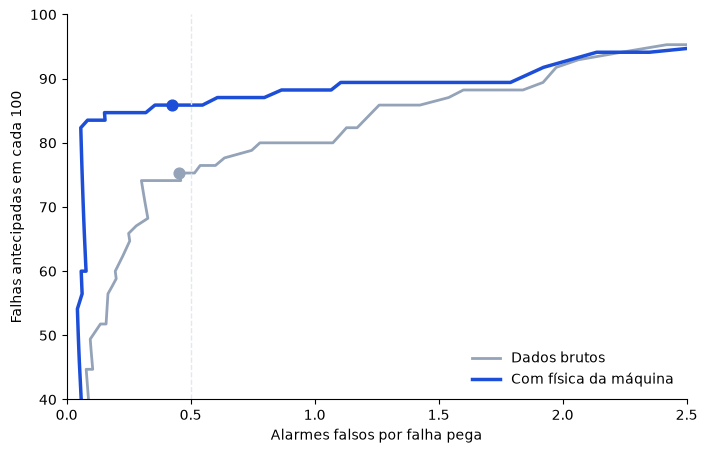

In [11]:
def curva(prob, y):
    pts = []
    for t in np.arange(0.02, 0.98, 0.01):
        alarme = prob >= t
        tp = (alarme & (y == 1)).sum(); fp = (alarme & (y == 0)).sum()
        if tp:
            pts.append((fp / tp, 100 * tp / (y == 1).sum()))
    return np.array(pts)

y_teste = teste[ALVO].to_numpy()
curvas = {nome: curva(r["prob"], y_teste) for nome, r in resultados.items()}

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(*curvas["brutas"].T, color="#94a3b8", lw=2, label="Dados brutos")
ax.plot(*curvas["fisica"].T, color="#1d4ed8", lw=2.5, label="Com física da máquina")
for nome, cor in [("brutas", "#94a3b8"), ("fisica", "#1d4ed8")]:
    r = resultados[nome]
    ax.scatter(r["falsos_por_acerto"], r["por_100"], color=cor, s=60, zorder=3)
ax.axvline(TETO_FALSOS_POR_ACERTO, color="#e2e8f0", lw=1, ls="--")
ax.set_xlim(0, 2.5); ax.set_ylim(40, 100)
ax.set_xlabel("Alarmes falsos por falha pega")
ax.set_ylabel("Falhas antecipadas em cada 100")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

## 8. Quando vale a pena ligar o alarme

Todo alarme gera uma inspeção. Para cada falha pega, a operação paga as inspeções
dos alarmes falsos que vieram junto. O alarme compensa quando:

> custo de uma falha  >  custo de uma inspeção × (1 + alarmes falsos por falha pega)

Não usamos valores em reais aqui — eles dependem de cada operação. O ponto de
equilíbrio abaixo vale para qualquer uma.

In [12]:
for nome, rotulo in [("brutas", "Dados brutos"), ("fisica", "Com física da máquina")]:
    r = resultados[nome]
    print(f"{rotulo:<22} compensa se uma falha custar mais que "
          f"{1 + r['falsos_por_acerto']:.2f} inspeções")

Dados brutos           compensa se uma falha custar mais que 1.45 inspeções
Com física da máquina  compensa se uma falha custar mais que 1.42 inspeções


## 9. O número

In [13]:
b, f = resultados["brutas"], resultados["fisica"]
print(f"Com o mesmo modelo e o mesmo teto de alarmes falsos,")
print(f"transformar as leituras em grandezas físicas da máquina")
print(f"sobe de {b['por_100']:.0f} para {f['por_100']:.0f} as falhas antecipadas em cada 100.")
print()
print(f"(teste: {f['tp']} de {f['tp'] + f['fn']} falhas pegas, "
      f"{f['fp']} alarmes falsos — {f['falsos_por_acerto']:.2f} por falha pega)")

Com o mesmo modelo e o mesmo teto de alarmes falsos,
transformar as leituras em grandezas físicas da máquina
sobe de 75 para 86 as falhas antecipadas em cada 100.

(teste: 73 de 85 falhas pegas, 31 alarmes falsos — 0.42 por falha pega)


## 10. Limitações

- **O dataset é sintético.** Os autores o geraram para imitar uma operação real,
  porque dados reais de manutenção quase nunca podem ser publicados.
- **As falhas foram geradas por regras sobre as mesmas grandezas que derivamos.**
  Falha por potência, por dissipação de calor e por sobrecarga seguem limiares de
  potência, diferença de temperatura e desgaste × torque. Por isso a versão "com
  física" encontra o padrão com tanta facilidade. Numa máquina real o ganho existe
  — é o mesmo raciocínio de um diagnóstico de campo —, mas deve ser **menor** do que
  o medido aqui.
- **Cada registro é um instante, não uma série.** O modelo não vê a tendência de
  subida da temperatura nem o histórico da máquina. Numa operação real, a série no
  tempo é o que dá antecedência para agir.
- **Antecedência não medida.** Este modelo diz *se* o ponto de operação é de falha,
  não *quanto tempo antes* dá para saber. Esse é o tema do projeto D2.
- **Falhas aleatórias ficam de fora por definição.** Parte das falhas do dataset
  (tipo RNF) foi gerada ao acaso e nenhum modelo as antecipa.

## Dados do painel interativo

O painel em `painel/index.html` recalcula tudo no navegador a partir destas
previsões reais do conjunto de teste — nenhum número do painel é digitado à mão.

In [14]:
import json, os
os.makedirs("painel", exist_ok=True)
tipo_falha = np.select([teste[c] == 1 for c in nomes], list(nomes.values()), default="sem tipo registrado")
exportar = {
    "y": teste[ALVO].astype(int).tolist(),
    "prob_brutas": np.round(resultados["brutas"]["prob"], 4).tolist(),
    "prob_fisica": np.round(resultados["fisica"]["prob"], 4).tolist(),
    "desgaste": teste["Tool wear"].astype(int).tolist(),
    "twf": teste["TWF"].astype(int).tolist(),
    "tipo": [t if y == 1 else "" for t, y in zip(tipo_falha, teste[ALVO])],
    "limiar": limiares,
    "desgaste_twf_todas": sorted(desgaste_twf.astype(int).tolist()),
    "acuracia_nunca_falha": round(float(acerto_nunca_falha), 4),
    "n_treino": len(treino),
}
with open("painel/dados.js", "w", encoding="utf-8") as fh:
    fh.write("window.D1 = " + json.dumps(exportar, ensure_ascii=False) + ";\n")
print(f"painel/dados.js: {len(exportar['y'])} registros de teste, {sum(exportar['y'])} falhas")

painel/dados.js: 2500 registros de teste, 85 falhas


## Capa do projeto

In [15]:
from matplotlib import font_manager
fonte = "Segoe UI" if any("Segoe UI" in f.name for f in font_manager.fontManager.ttflist) else "DejaVu Sans"
plt.rcParams["font.family"] = fonte

TINTA, TINTA2, APOIO, ACAO, METRICA, REGUA = "#0f172a", "#475569", "#64748b", "#1d4ed8", "#0e7490", "#e2e8f0"
fig = plt.figure(figsize=(10.8, 13.5), dpi=100, facecolor="#ffffff")

fig.text(0.08, 0.93, "PROJETO D1 · MANUTENÇÃO PREDITIVA", fontsize=15, color=APOIO,
         fontweight="bold")
fig.text(0.08, 0.855, "O mesmo modelo.\nOutra forma de olhar os dados.", fontsize=38,
         color=TINTA, fontweight="bold", va="top", linespacing=1.15)

fig.text(0.08, 0.66, f"{b['por_100']:.0f}", fontsize=110, color="#94a3b8", fontweight="bold")
fig.text(0.34, 0.69, "→", fontsize=70, color=APOIO)
fig.text(0.46, 0.66, f"{f['por_100']:.0f}", fontsize=110, color=METRICA, fontweight="bold")
fig.text(0.08, 0.62, "falhas antecipadas em cada 100, com o mesmo teto\nde 1 alarme falso a cada 2 acertos",
         fontsize=19, color=TINTA2, va="top", linespacing=1.35)

ax = fig.add_axes([0.11, 0.17, 0.82, 0.35])
ax.plot(*curvas["brutas"].T, color="#94a3b8", lw=3.5)
ax.plot(*curvas["fisica"].T, color=ACAO, lw=4.5)
ax.scatter(b["falsos_por_acerto"], b["por_100"], color="#94a3b8", s=140, zorder=3)
ax.scatter(f["falsos_por_acerto"], f["por_100"], color=ACAO, s=140, zorder=3)
ax.text(0.95, 71, "leituras brutas", color=APOIO, fontsize=17)
ax.text(1.55, curvas["fisica"][:, 1].max() - 1, "com física da máquina", color=ACAO,
        fontsize=17, fontweight="bold")
ax.set_xlim(0, 2.5); ax.set_ylim(40, 100)
ax.set_xlabel("alarmes falsos por falha pega", fontsize=16, color=APOIO)
ax.set_ylabel("falhas antecipadas em cada 100", fontsize=16, color=APOIO)
ax.tick_params(colors=APOIO, labelsize=14)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
for lado in ["left", "bottom"]:
    ax.spines[lado].set_color(REGUA)

fig.text(0.08, 0.06, "Potência, diferença de temperatura e desgaste × torque — o que um técnico\nolharia no campo.  Dataset AI4I 2020 (UCI), sintético.",
         fontsize=15, color=APOIO, linespacing=1.4)
fig.savefig("capa.png", dpi=100, facecolor="#ffffff")
plt.close(fig)
print("capa.png salva")

capa.png salva
